# Figure 3: 
Regression of activity v metabolic rates

## Load data and shared style

Required files:
- batch_summary.csv
- signal_rate_summary.csv
- photeros.mplstyle
- figure_style.py

In [17]:
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Toggle: set to True to include trials 4 and 4.5 (unfiltered), False to exclude them
use_unfiltered = False

# Load shared style + palette
style_dir_candidates = [
    Path.cwd() / 'notebooks' / 'styles',
    Path.cwd() / 'styles',
    Path.cwd() / '..' / 'notebooks' / 'styles',
]

style_dir = next(
    (
        p.resolve()
        for p in style_dir_candidates
        if (p / 'photeros.mplstyle').exists() and (p / 'figure_style.py').exists()
    ),
    None,
)

if style_dir is None:
    raise FileNotFoundError('Could not find shared style files in notebooks/styles')

style_path = style_dir / 'photeros.mplstyle'
module_path = style_dir / 'figure_style.py'

spec = importlib.util.spec_from_file_location('figure_style_shared', module_path)
figure_style = importlib.util.module_from_spec(spec)
spec.loader.exec_module(figure_style)

figure_style.apply_photeros_style(style_path)
palette = figure_style.get_palette()

LIGHT_BLUE = palette['light_blue']
DARK_BLUE = palette['dark_blue']
LIGHT_ORANGE = palette['light_orange']
DARK_ORANGE = palette['dark_orange']

# Load processed summary data
candidate_paths = [
    Path.cwd() / '../data/processed/batch_summary.csv',
    Path.cwd() / 'data/processed/batch_summary.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv'),
]

data_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/processed/batch_summary.csv')

agg_df = pd.read_csv(data_path)
reg_df = agg_df.copy() if use_unfiltered else agg_df[agg_df['filtered'] == True].copy()

print(f'Shared style loaded from: {style_path}')
print(f'Loaded {len(reg_df)} rows for Figure 3 from: {data_path}')

Shared style loaded from: /Users/oakley/Documents/GitHub/signal_respirometry/notebooks/styles/photeros.mplstyle
Loaded 58 rows for Figure 3 from: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/batch_summary.csv


## Regress activity estimates against metabolic rate measures

In [2]:
# Merge activity estimates (signal rate) with metabolic rates
from scipy import stats

signal_rate_candidates = [
    Path.cwd() / '../data/processed/signal_rate_summary.csv',
    Path.cwd() / 'data/processed/signal_rate_summary.csv',
    Path('/Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv'),
]

signal_rate_path = next((p.resolve() for p in signal_rate_candidates if p.exists()), None)
if signal_rate_path is None:
    raise FileNotFoundError('Could not find data/processed/signal_rate_summary.csv')

signal_df = pd.read_csv(signal_rate_path)

# Merge signal rate into cylinder rows by trial, brick, channel
cylinder_mask = reg_df['vessel'] == 'cylinder'
reg_df_cyl = reg_df[cylinder_mask].copy()
reg_df_non_cyl = reg_df[~cylinder_mask].copy()

merged_cyl = pd.merge(
    reg_df_cyl,
    signal_df[['trial', 'brick', 'channel', 'signal_rate']],
    on=['trial', 'brick', 'channel'],
    how='left',
)

# Non-cylinder rows have no courtship signal estimate
reg_df_non_cyl['signal_rate'] = 0.0
merged_df = pd.concat([merged_cyl, reg_df_non_cyl], ignore_index=True)

print(f'Loaded activity estimates from: {signal_rate_path}')
print(f'Merged rows: {len(merged_df)}')
print(f'Cylinder rows with signal_rate: {merged_df[merged_df["vessel"] == "cylinder"]["signal_rate"].notna().sum()}')

display(merged_df.head())

Loaded activity estimates from: /Users/oakley/Documents/GitHub/signal_respirometry/data/processed/signal_rate_summary.csv
Merged rows: 58
Cylinder rows with signal_rate: 8


,trial,brick,channel,n,total_mass_mg,corrected_mass_mg,RMR,A,M,temp_C,vessel,date,environment,notes,filtered,signal_rate
0,trial1,box3,Ch2,20.0,7.6,7.238095,8.546660,6.628954,9.384154,28.233,cylinder,10Nov2025,night,NaN,True,9.745342
1,trial1,box3,Ch3,20.0,6.5,7.222222,8.352764,6.475010,9.166227,28.233,cylinder,10Nov2025,night,NaN,True,0.981366
2,trial1,box3,Ch4,20.0,5.5,7.333333,7.555755,5.879572,8.323307,28.233,cylinder,10Nov2025,night,NaN,True,4.161491
3,trial3,box2,Ch2,20.0,4.9,4.900000,5.227565,3.677824,5.206443,26.750,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro",True,0.174402
4,trial3,box2,Ch3,20.0,4.7,4.700000,3.558230,2.477428,3.507124,26.750,cylinder,12Nov2025,night,"Ch2 closest to GoPro, Ch4 farthest from GoPro",True,0.485232


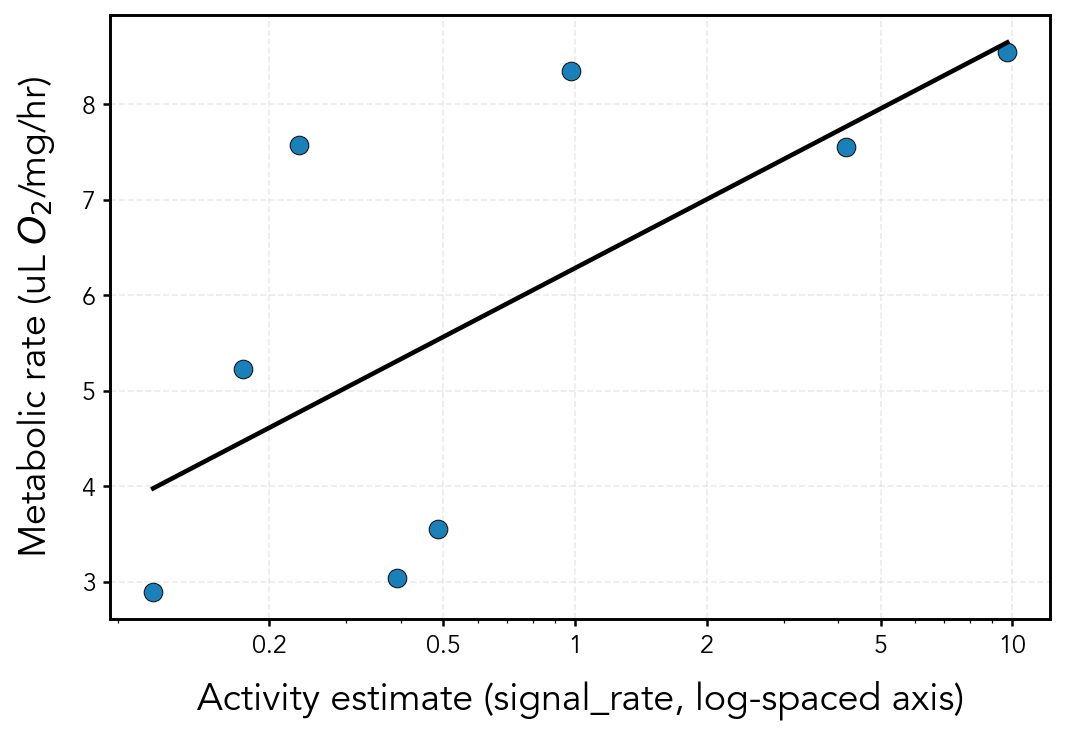

Regression summary (log10(signal_rate) -> RMR):
  slope: 2.3905
  intercept: 6.2853
  R^2: 0.4471
  p-value: 6.9859e-02
  std err: 1.0853


In [20]:
# Figure 3 regression: cylinder signal_rate vs metabolic rate (RMR)
# Uses semi-log x-axis with plain-number tick labels

cyl_df = merged_df[
    (merged_df['vessel'] == 'cylinder') &
    (merged_df['signal_rate'].notna()) &
    (merged_df['signal_rate'] > 0) &
    (merged_df['RMR'].notna())
] .copy()

if cyl_df.empty:
    print('No cylinder data available for regression plotting.')
else:
    cyl_df['signal_rate_log10'] = np.log10(cyl_df['signal_rate'])

    slope, intercept, r_value, p_value, stderr = stats.linregress(
        cyl_df['signal_rate_log10'], cyl_df['RMR']
    )
    r2 = r_value ** 2

    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    ax.scatter(
        cyl_df['signal_rate'],
        cyl_df['RMR'],
        s=80,
        color=DARK_BLUE,
        edgecolors='black',
        linewidth=0.5,
        alpha=0.9,
        zorder=3,
    )

    # Regression line in original x-space from model fit in log10-space.
    x_line = np.geomspace(cyl_df['signal_rate'].min(), cyl_df['signal_rate'].max(), 200)
    y_line = intercept + slope * np.log10(x_line)
    ax.plot(x_line, y_line, color='black', linewidth=2.2, zorder=4)

    ax.set_xscale('log')
    ax.set_xlabel('Activity estimate (signal_rate, log-spaced axis)', fontsize=18, labelpad=10)
    ax.set_ylabel('Metabolic rate (uL $O_2$/mg/hr)', fontsize=18, labelpad=12)
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True, linestyle='--', alpha=0.25)

    # Match comparative style: log spacing but plain (unlogged) numeric tick labels.
    tick_candidates = np.array([0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20], dtype=float)
    xmin = float(cyl_df['signal_rate'].min())
    xmax = float(cyl_df['signal_rate'].max())
    xticks = tick_candidates[(tick_candidates >= xmin * 0.95) & (tick_candidates <= xmax * 1.05)]
    if len(xticks) < 3:
        # Fallback if data range does not overlap much with default candidates.
        xticks = np.geomspace(xmin, xmax, min(5, len(cyl_df)))
    ax.set_xticks(xticks)
    ax.set_xticklabels([f'{t:g}' for t in xticks])

    plt.tight_layout()
    plt.show()

    print('Regression summary (log10(signal_rate) -> RMR):')
    print(f'  slope: {slope:.4f}')
    print(f'  intercept: {intercept:.4f}')
    print(f'  R^2: {r2:.4f}')
    print(f'  p-value: {p_value:.4e}')
    print(f'  std err: {stderr:.4f}')

In [7]:
# Regression statistics with confidence intervals + robust comparison
try:
    import statsmodels.api as sm
except ImportError:
    print('statsmodels is required for confidence intervals and robust regression.')
    print('Install with: pip install statsmodels')
else:
    if 'cyl_df' not in locals() or cyl_df.empty:
        print('No cylinder data available. Run the regression plot cell first.')
    else:
        stats_df = cyl_df.copy()
        X = sm.add_constant(stats_df['signal_rate_log10'])
        y = stats_df['RMR']

        # Ordinary least squares
        ols_model = sm.OLS(y, X).fit()

        # Robust linear model (Huber T)
        rlm_model = sm.RLM(y, X, M=sm.robust.norms.HuberT()).fit()

        ols_ci = ols_model.conf_int(alpha=0.05)

        summary_table = pd.DataFrame({
            'model': ['OLS', 'RLM (HuberT)'],
            'n': [int(len(stats_df)), int(len(stats_df))],
            'slope_log10_signal_rate': [float(ols_model.params['signal_rate_log10']), float(rlm_model.params['signal_rate_log10'])],
            'intercept': [float(ols_model.params['const']), float(rlm_model.params['const'])],
            'slope_ci95_lower': [float(ols_ci.loc['signal_rate_log10', 0]), np.nan],
            'slope_ci95_upper': [float(ols_ci.loc['signal_rate_log10', 1]), np.nan],
            'intercept_ci95_lower': [float(ols_ci.loc['const', 0]), np.nan],
            'intercept_ci95_upper': [float(ols_ci.loc['const', 1]), np.nan],
            'r_squared': [float(ols_model.rsquared), np.nan],
            'p_value_slope': [float(ols_model.pvalues['signal_rate_log10']), np.nan],
        })

        print('Regression statistics (activity -> metabolic rate)')
        print('=' * 70)
        display(summary_table)

        print('\nCaption-ready sentence:')
        print(
            f"OLS regression of metabolic rate on log10(activity estimate) gave a slope of "
            f"{ols_model.params['signal_rate_log10']:.3f} "
            f"(95% CI {ols_ci.loc['signal_rate_log10', 0]:.3f} to {ols_ci.loc['signal_rate_log10', 1]:.3f}; "
            f"R^2={ols_model.rsquared:.3f}; p={ols_model.pvalues['signal_rate_log10']:.3e}; n={len(stats_df)})."
        )

        print('\nRobust comparison (HuberT):')
        print(
            f"Robust slope estimate = {rlm_model.params['signal_rate_log10']:.3f}, "
            f"intercept = {rlm_model.params['const']:.3f}."
        )

Regression statistics (activity -> metabolic rate)


,model,n,slope_log10_signal_rate,intercept,slope_ci95_lower,slope_ci95_upper,intercept_ci95_lower,intercept_ci95_upper,r_squared,p_value_slope
0,OLS,8,2.390477,6.285345,-0.265248,5.046201,4.521024,8.049666,0.44706,0.069859
1,RLM (HuberT),8,2.390477,6.285345,NaN,NaN,NaN,NaN,NaN,NaN



Caption-ready sentence:
OLS regression of metabolic rate on log10(activity estimate) gave a slope of 2.390 (95% CI -0.265 to 5.046; R^2=0.447; p=6.986e-02; n=8).

Robust comparison (HuberT):
Robust slope estimate = 2.390, intercept = 6.285.


In [4]:
# Save Figure 3 to files
figures_dir = Path.cwd() / '../figures'
figures_dir.mkdir(parents=True, exist_ok=True)

if 'fig' in locals():
    png_path = (figures_dir / 'Figure3_Regression.png').resolve()
    pdf_path = (figures_dir / 'Figure3_Regression.pdf').resolve()

    fig.savefig(png_path, dpi=600, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')

    print(f'Saved PNG: {png_path}')
    print(f'Saved PDF: {pdf_path}')
else:
    print('No figure object found. Run the regression plot cell first.')

Saved PNG: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure3_Regression.png
Saved PDF: /Users/oakley/Documents/GitHub/signal_respirometry/figures/Figure3_Regression.pdf


## Power analysis

In [16]:
# Post hoc power analysis for the Figure 3 regression slope
# Uses Fisher z approximation for the correlation test (H0: rho = 0).
from scipy.stats import norm

alpha = 0.05
target_powers = [0.80, 0.90]

# Use OLS model if available; otherwise derive r and n from cyl_df
if 'ols_model' in locals():
    r2_obs = float(ols_model.rsquared)
    n_obs = int(ols_model.nobs)
    slope_sign = np.sign(float(ols_model.params['signal_rate_log10']))
    r_obs = slope_sign * np.sqrt(r2_obs)
elif 'cyl_df' in locals() and len(cyl_df) >= 4:
    x = cyl_df['signal_rate_log10'] if 'signal_rate_log10' in cyl_df.columns else np.log10(cyl_df['signal_rate'])
    y = cyl_df['RMR']
    _, _, r_val, _, _ = stats.linregress(x, y)
    r_obs = float(r_val)
    r2_obs = float(r_obs ** 2)
    n_obs = int(len(cyl_df))
else:
    raise RuntimeError('Need regression results first. Run Cells 5-7 before power analysis.')

if n_obs < 4:
    raise ValueError('Power approximation requires n >= 4.')

if abs(r_obs) >= 1.0:
    raise ValueError('Observed correlation magnitude is 1.0; power analysis is undefined.')

def approx_power_corr(n, r, alpha=0.05):
    # Fisher z under alternative: Z ~ N(delta, 1) where delta = sqrt(n-3)*atanh(r)
    zcrit = norm.ppf(1 - alpha / 2.0)
    delta = np.sqrt(n - 3.0) * np.arctanh(r)
    return (1 - norm.cdf(zcrit - delta)) + norm.cdf(-zcrit - delta)

achieved_power = approx_power_corr(n_obs, r_obs, alpha=alpha)

required_rows = []
for target in target_powers:
    required_n = None
    for n_try in range(4, 1001):
        pwr = approx_power_corr(n_try, r_obs, alpha=alpha)
        if pwr >= target:
            required_n = n_try
            break
    required_rows.append({
        'target_power': target,
        'required_n_total': required_n,
        'additional_n_needed': None if required_n is None else max(0, required_n - n_obs),
    })

power_summary = pd.DataFrame({
    'alpha': [alpha],
    'observed_n': [n_obs],
    'observed_r': [r_obs],
    'observed_R2': [r2_obs],
    'achieved_power_approx': [achieved_power],
})

required_df = pd.DataFrame(required_rows)

print('Power analysis for Figure 3 regression slope (approximate)')
print('=' * 72)
display(power_summary)
display(required_df)

print('\nInterpretation:')
print(
    f"With n={n_obs}, observed r={r_obs:.3f} (R^2={r2_obs:.3f}), approximate power is {achieved_power:.3f} at alpha={alpha:.2f}."
)

n80 = required_df.loc[required_df['target_power'] == 0.80, 'required_n_total'].iloc[0]
n90 = required_df.loc[required_df['target_power'] == 0.90, 'required_n_total'].iloc[0]
add80 = required_df.loc[required_df['target_power'] == 0.80, 'additional_n_needed'].iloc[0]
add90 = required_df.loc[required_df['target_power'] == 0.90, 'additional_n_needed'].iloc[0]

print('\nCaption-ready sentence:')
print(
    f"Post hoc power analysis (Fisher-z approximation) indicated {achieved_power:.2f} power "
    f"to detect the observed association (R^2={r2_obs:.2f}, n={n_obs}, alpha={alpha:.2f}); "
    f"approximately n={n80} ({add80} additional) and n={n90} ({add90} additional) "
    f"would be needed for 0.80 and 0.90 power, respectively."
 )

Power analysis for Figure 3 regression slope (approximate)


,alpha,observed_n,observed_r,observed_R2,achieved_power_approx
0,0.05,8,0.668626,0.44706,0.439418


,target_power,required_n_total,additional_n_needed
0,0.8,16,8
1,0.9,20,12



Interpretation:
With n=8, observed r=0.669 (R^2=0.447), approximate power is 0.439 at alpha=0.05.

Caption-ready sentence:
Post hoc power analysis (Fisher-z approximation) indicated 0.44 power to detect the observed association (R^2=0.45, n=8, alpha=0.05); approximately n=16 (8 additional) and n=20 (12 additional) would be needed for 0.80 and 0.90 power, respectively.
